# PM review: momentum reversal-risk prototype

**Purpose.** Validate the artifacts already produced, show the economically interpretable results, and frame a credible prototype story for a portfolio manager or researcher.

**Central takeaway.** The prototype does not claim to forecast crashes with a production-ready probability. It separates three useful objects:

1. **Observed context:** point-in-time market, momentum-leg, exposure, and return-dispersion facts.
2. **Transparent domain state:** a Daniel–Moskowitz-inspired checklist that distinguishes stressed preconditions from active reversal triggers.
3. **Secondary statistical benchmark:** the saved B2 out-of-sample score, retained for comparison but not allowed to define the domain state.

The notebook is deliberately a prototype review, not an investment recommendation or production sign-off.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.monitoring.contracts import DomainRiskState, RiskState, StructuredMarketContext
from src.monitoring.domain_risk import build_domain_risk_state
from src.monitoring.market_context import build_structured_market_context
from src.utils.io import read_json, sha256_file

DEBUG = ROOT / "outputs" / "debug"
SAVED_DATES = ("2009-03-06", "2024-01-05")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

print("Repository root detected; all paths below are repository-relative.")
print(f"Saved PM-review dates: {', '.join(SAVED_DATES)}")

Repository root detected; all paths below are repository-relative.
Saved PM-review dates: 2009-03-06, 2024-01-05


## 1. Validate the saved prototype artifacts

A useful PM demo should be reproducible, not a hand-built slide. The checks below:

- parse every JSON artifact through its typed contract;
- rebuild the context and domain state from the underlying repository data;
- require exact equality with the saved objects; and
- verify every recorded input hash.

These checks validate deterministic construction and provenance. They do **not** establish predictive skill or economic optimality.

In [2]:
def provenance_is_current(items):
    checks = []
    for item in items:
        path = Path(item.path)
        resolved = path if path.is_absolute() else ROOT / path
        checks.append(resolved.is_file() and sha256_file(resolved) == item.sha256)
    return all(checks)


contexts = {}
domain_states = {}
legacy_states = {}
validation_rows = []

for date in SAVED_DATES:
    context_path = DEBUG / f"structured_context_{date}.json"
    domain_path = DEBUG / f"domain_risk_state_{date}.json"
    legacy_path = DEBUG / f"risk_state_{date}.json"

    context = StructuredMarketContext.from_dict(read_json(context_path))
    domain_state = DomainRiskState.from_dict(read_json(domain_path))
    legacy_state = RiskState.from_dict(read_json(legacy_path))

    rebuilt_context = build_structured_market_context(as_of_date=pd.Timestamp(date))
    rebuilt_domain = build_domain_risk_state(
        context=rebuilt_context,
        legacy_risk_state=legacy_state,
        provenance=domain_state.provenance,
    )

    contexts[date] = context
    domain_states[date] = domain_state
    legacy_states[date] = legacy_state
    validation_rows.append({
        "as_of_date": date,
        "context_contract": "PASS",
        "domain_contract": "PASS",
        "context_exact_rebuild": context == rebuilt_context,
        "domain_exact_rebuild": domain_state == rebuilt_domain,
        "context_provenance": provenance_is_current(context.provenance),
        "domain_provenance": provenance_is_current(domain_state.provenance),
    })

validation = pd.DataFrame(validation_rows)
boolean_checks = validation.select_dtypes(include="bool")
assert boolean_checks.to_numpy().all(), "At least one artifact validation check failed"
display(validation)
print("All saved-artifact checks passed.")

,as_of_date,context_contract,domain_contract,context_exact_rebuild,domain_exact_rebuild,context_provenance,domain_provenance
0,2009-03-06,PASS,PASS,True,True,True,True
1,2024-01-05,PASS,PASS,True,True,True,True


All saved-artifact checks passed.


## 2. What has been built and how much to trust it

The strongest claim is engineering and research traceability: inputs are point-in-time filtered, state rules are inspectable, and artifacts rebuild exactly. Model quality is more limited. B2 shows some ranking information, but its calibration is not stable enough to anchor a PM decision.

In [3]:
prototype_stack = pd.DataFrame([
    {
        "layer": "Structured market context",
        "status": "Validated in this notebook",
        "credible use": "Describe market, factor legs, exposure change, and proxy state",
        "main limitation": "Public revised data; positioning is a return-dispersion proxy",
    },
    {
        "layer": "Transparent domain state",
        "status": "Validated in this notebook",
        "credible use": "Separate panic preconditions from observable reversal triggers",
        "main limitation": "Heuristic thresholds are not fitted or economically optimized",
    },
    {
        "layer": "B0/B1/B2 baselines",
        "status": "Purged development plus final holdout",
        "credible use": "Secondary ranking benchmark and research comparator",
        "main limitation": "Sparse events and unstable absolute probability calibration",
    },
    {
        "layer": "Retrieved/classified evidence fixtures",
        "status": "Prototype plumbing only",
        "credible use": "Test schemas, timestamp controls, and audit trail",
        "main limitation": "Not yet aligned to the new domain state or broad enough for a PM claim",
    },
])
display(prototype_stack)

,layer,status,credible use,main limitation
0,Structured market context,Validated in this notebook,"Describe market, factor legs, exposure change,...",Public revised data; positioning is a return-d...
1,Transparent domain state,Validated in this notebook,Separate panic preconditions from observable r...,Heuristic thresholds are not fitted or economi...
2,B0/B1/B2 baselines,Purged development plus final holdout,Secondary ranking benchmark and research compa...,Sparse events and unstable absolute probabilit...
3,Retrieved/classified evidence fixtures,Prototype plumbing only,"Test schemas, timestamp controls, and audit trail",Not yet aligned to the new domain state or bro...


In [4]:
metrics = pd.read_csv(ROOT / "outputs" / "baseline_metrics.csv")
model_review = metrics.loc[
    metrics["baseline"].isin(["B1", "B2"]),
    [
        "scope", "horizon_days", "baseline", "event_episodes",
        "log_loss", "brier_score", "pr_auc", "roc_auc",
        "calibration_slope", "event_capture_top_risk_decile",
    ],
].copy()
display(model_review.round(3))

holdout_20_episodes = int(metrics.loc[
    metrics["scope"].eq("holdout") & metrics["horizon_days"].eq(20),
    "event_episodes",
].iloc[0])
print(
    f"Guardrail: the 20-day holdout contains only {holdout_20_episodes} "
    "episode, so its ranking and calibration statistics are descriptive only."
)

,scope,horizon_days,baseline,event_episodes,log_loss,brier_score,pr_auc,roc_auc,calibration_slope,event_capture_top_risk_decile
1,development,5,B1,99,0.343,0.090,0.300,0.771,0.369,0.356
2,development,5,B2,99,0.944,0.168,0.280,0.788,0.177,0.351
4,development,20,B1,33,0.297,0.081,0.374,0.811,0.464,0.426
5,development,20,B2,33,0.613,0.113,0.249,0.740,0.172,0.376
7,holdout,5,B1,17,0.171,0.040,0.097,0.636,1.273,0.129
8,holdout,5,B2,17,0.171,0.040,0.079,0.655,0.739,0.194
10,holdout,20,B1,1,0.094,0.015,0.012,0.428,-3.080,0.000
11,holdout,20,B2,1,0.085,0.015,0.014,0.558,0.101,0.000


Guardrail: the 20-day holdout contains only 1 episode, so its ranking and calibration statistics are descriptive only.


## 3. Historical cases: precondition → reversal → non-trigger

The saved dates validate the artifact interface. For economic interpretation, 2009-03-23 is rebuilt live as an additional checkpoint: it captures the rebound phase after the 2009-03-06 panic setup.

In [5]:
scenario_order = ("2009-03-06", "2009-03-23", "2024-01-05")
scenario_labels = {
    "2009-03-06": "2009 panic setup",
    "2009-03-23": "2009 rebound",
    "2024-01-05": "2024 comparison",
}

scenario_contexts = dict(contexts)
scenario_states = dict(domain_states)
scenario_contexts["2009-03-23"] = build_structured_market_context(
    as_of_date=pd.Timestamp("2009-03-23")
)
scenario_states["2009-03-23"] = build_domain_risk_state(
    context=scenario_contexts["2009-03-23"]
)

scorecard_rows = []
for date in scenario_order:
    context = scenario_contexts[date]
    state = scenario_states[date]
    core_triggered = sum(
        component.triggered
        for component in state.components
        if component.category in {"precondition", "trigger"}
    )
    scorecard_rows.append({
        "case": scenario_labels[date],
        "date": date,
        "domain_state": state.state.replace("_", " ").title(),
        "core_checks": f"{core_triggered}/4",
        "market_504d": context.market_return_504d,
        "vol_percentile": context.market_volatility_percentile_126d,
        "market_5d": context.market_return_5d,
        "loser_minus_winner_5d": context.loser_minus_winner_return_5d,
        "momentum_drawdown": context.momentum_drawdown_252d,
        "positioning_proxy_percentile": context.positioning_proxy_percentile,
    })

scorecard = pd.DataFrame(scorecard_rows)
pm_scorecard = scorecard.copy()
for column in (
    "market_504d", "vol_percentile", "market_5d",
    "loser_minus_winner_5d", "momentum_drawdown",
    "positioning_proxy_percentile",
):
    pm_scorecard[column] = pm_scorecard[column].map(
        lambda value: "n/a" if pd.isna(value) else f"{value:.1%}"
    )
display(pm_scorecard)

,case,date,domain_state,core_checks,market_504d,vol_percentile,market_5d,loser_minus_winner_5d,momentum_drawdown,positioning_proxy_percentile
0,2009 panic setup,2009-03-06,Stressed Precondition,2/4,-47.9%,100.0%,-7.0%,-7.8%,-11.9%,99.1%
1,2009 rebound,2009-03-23,Active Reversal,4/4,-39.2%,100.0%,9.4%,11.4%,-32.6%,99.7%
2,2024 comparison,2024-01-05,Normal,0/4,-1.0%,50.0%,-2.2%,1.9%,-14.7%,83.1%


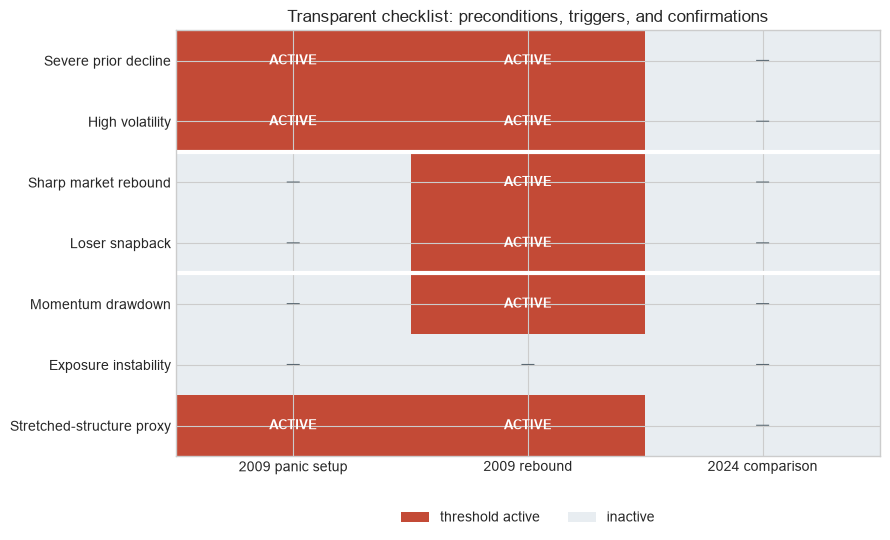

In [6]:
component_order = [component.component for component in scenario_states["2009-03-06"].components]
component_labels = {
    "severe_prior_market_decline": "Severe prior decline",
    "high_market_volatility": "High volatility",
    "sharp_market_rebound": "Sharp market rebound",
    "loser_snapback": "Loser snapback",
    "momentum_drawdown_confirmation": "Momentum drawdown",
    "exposure_instability_confirmation": "Exposure instability",
    "stretched_momentum_structure_proxy": "Stretched-structure proxy",
}
matrix = []
for component_name in component_order:
    matrix.append([
        int(next(
            component.triggered
            for component in scenario_states[date].components
            if component.component == component_name
        ))
        for date in scenario_order
    ])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.imshow(matrix, aspect="auto", cmap=ListedColormap(["#e8edf1", "#c34a36"]), vmin=0, vmax=1)
ax.set_xticks(range(len(scenario_order)), [scenario_labels[date] for date in scenario_order])
ax.set_yticks(range(len(component_order)), [component_labels[name] for name in component_order])
for row_index, row in enumerate(matrix):
    for column_index, value in enumerate(row):
        ax.text(column_index, row_index, "ACTIVE" if value else "—", ha="center", va="center", color="white" if value else "#52616b", fontsize=9, fontweight="bold" if value else "normal")
ax.axhline(1.5, color="white", linewidth=3)
ax.axhline(3.5, color="white", linewidth=3)
ax.set_title("Transparent checklist: preconditions, triggers, and confirmations")
ax.legend(
    handles=[Patch(facecolor="#c34a36", label="threshold active"), Patch(facecolor="#e8edf1", label="inactive")],
    loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False,
)
fig.tight_layout()
plt.show()

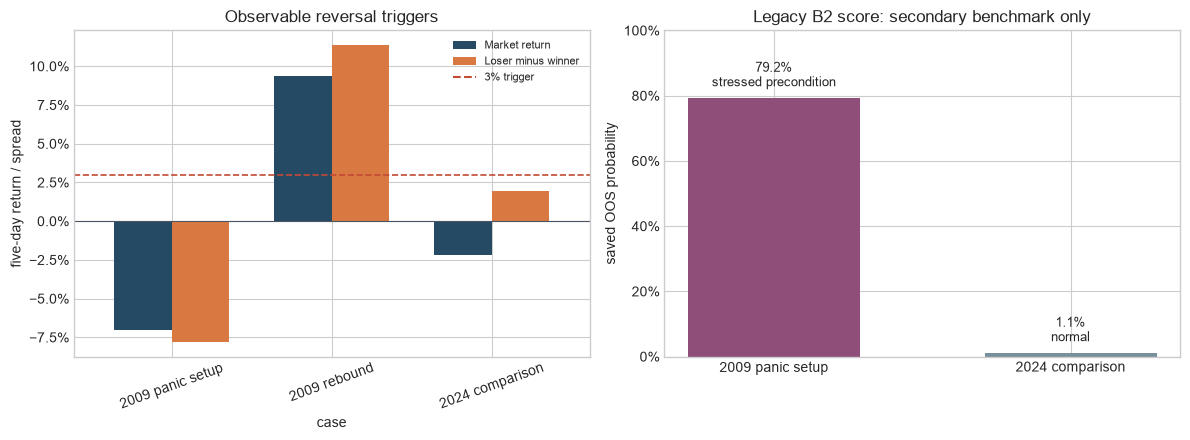

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

trigger_plot = scorecard.set_index("case")[["market_5d", "loser_minus_winner_5d"]]
trigger_plot.plot.bar(
    ax=axes[0], color=["#244a64", "#d97941"], width=0.72,
)
axes[0].axhline(0.03, color="#c34a36", linestyle="--", linewidth=1.2, label="3% trigger")
axes[0].axhline(0, color="#4b5563", linewidth=0.8)
axes[0].set_title("Observable reversal triggers")
axes[0].set_ylabel("five-day return / spread")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(
    handles=[
        Patch(facecolor="#244a64", label="Market return"),
        Patch(facecolor="#d97941", label="Loser minus winner"),
        Line2D([0], [0], color="#c34a36", linestyle="--", label="3% trigger"),
    ],
    fontsize=8,
)

benchmark_dates = list(SAVED_DATES)
benchmark_values = [domain_states[date].legacy_benchmark_probability for date in benchmark_dates]
bars = axes[1].bar(
    [scenario_labels[date] for date in benchmark_dates],
    benchmark_values,
    color=["#8f4e7a", "#78909c"], width=0.58,
)
for bar, date, probability in zip(bars, benchmark_dates, benchmark_values):
    state_label = domain_states[date].state.replace("_", " ")
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{probability:.1%}\n{state_label}",
        ha="center", va="bottom", fontsize=9,
    )
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Legacy B2 score: secondary benchmark only")
axes[1].set_ylabel("saved OOS probability")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

fig.tight_layout()
plt.show()

### How to read the cases

- **2009-03-06 — stressed precondition.** The market had fallen about 48% over 504 trading days and volatility was near the top of its expanding history. However, the five-day market move and loser-minus-winner spread were still negative. The prototype correctly says “fragile setup,” not “reversal underway.” The return-dispersion proxy was also extreme, but it is only a proxy confirmation.
- **2009-03-23 — active reversal.** The panic preconditions persisted, while the five-day market rebound reached about 9% and losers beat winners by about 11 percentage points. Both observable reversal triggers were active. This is the mechanism transition a PM can recognize and challenge.
- **2024-01-05 — normal comparison.** The severe-decline and high-volatility pair was absent, so isolated noise could not escalate the state. No checklist component was active.

**Why the separation matters:** on 2009-03-06, B2 was already high at roughly 79%, while the domain state still showed preconditions rather than an active reversal. The score can flag statistical similarity; the checklist identifies which economic mechanism is observable now.

## 4. The PM story to tell

### Thirty-second version

> We are not offering a black-box crash probability. We built a point-in-time monitor that separates the setup for a momentum reversal from the reversal itself. The setup is a deeply impaired, high-volatility market; the trigger is a sharp market rebound accompanied by a loser snapback. In March 2009 the monitor moves from stressed precondition on March 6 to active reversal on March 23, which is the behavior we want economically. A legacy statistical score is shown only as a secondary comparator. The immediate use is structured exposure review and scenario discussion—not automatic trading.

### What to put in front of a PM

1. **Headline state and change:** normal, stressed precondition, reversal watch, or active reversal; show the prior-session state beside it.
2. **Four core checks:** severe prior decline, high volatility, sharp rebound, and loser snapback. These should fit on one checklist.
3. **Leg evidence:** show winner and loser behavior separately. A momentum reversal is not adequately described by the market index alone.
4. **Confirmations with honest labels:** momentum drawdown, beta instability, and return-dispersion proxy. Confirmations add context but cannot create an alert by themselves.
5. **Secondary model context:** show B2 only if it helps frame historical similarity, with its calibration warning next to the number.

### Decision-use framing

- **Normal:** routine monitoring; no prototype-driven action.
- **Stressed precondition:** inspect gross/net factor exposure, liquidity, and loser-side short concentration; prepare rebound scenarios.
- **Reversal watch:** escalate review because one observable reversal trigger is active; examine breadth and exposure decomposition.
- **Active reversal:** treat the configuration as a live scenario requiring PM judgment, position-level review, and execution/liquidity planning.

The state is a meeting and research aid. It does not prescribe sizing, timing, or a trade.

## 5. Claims discipline and next validation

### Claims this prototype can support

- The artifacts are deterministic, typed, and traceable to hashed local inputs.
- Point-in-time filters prevent future rows from entering the assessment calculation.
- The 2009 checkpoints produce an economically coherent transition from panic setup to reversal.
- The rule hierarchy prevents confirmations or the positioning proxy from creating a reversal state alone.

### Claims it cannot yet support

- “This is a calibrated probability of a momentum crash.”
- “The thresholds are optimal or validated as trading cutoffs.”
- “The dispersion proxy measures actual investor crowding, leverage, or flows.”
- “One historical case establishes broad out-of-sample robustness.”
- “The existing retrieved documents constitute production-quality explanatory evidence.”

### Recommended next research task

Align evidence retrieval to the new domain mechanisms and build a small, timestamp-verified casebook across several distinct reversal and false-positive episodes. Keep the first version manual and auditable: the objective is to learn whether the state creates useful PM conversations before optimizing thresholds or adding an AI narrative layer.